In [ ]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (SETUP, CONNECTIVITY & AESTHETICS)
# ==============================================================================
# Purpose: 1. Silence warnings for a clean output.
#          2. Mount Google Drive and connect to the Golden Master DB.
#          3. Apply the "Opus Lab" Visual Canon (Standardized Aesthetics).
# ==============================================================================

# --- 1. HYGIENE PROTOCOL ---
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
pd.options.mode.chained_assignment = None  # Silence SettingWithCopy

# --- 2. IMPORTS ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import sqlite3
from google.colab import drive

# --- 3. CONNECTIVITY ---
print("⏳ Mounting Google Drive...")
try:
    drive.mount('/content/drive')
    print("✅ Drive Mounted.")
except:
    print("ℹ️ Drive already mounted or running locally.")

# DEFINITIVE PATH
DB_PATH = '/content/drive/MyDrive/_Pienza/Assets/Database/opus.db'

if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    print(f"✅ Database found: {DB_PATH}")
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print("✅ SQL Engine Active.")

# --- 4. VISUAL CANON (OPUS LAB THEME) ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY,
    'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Lab (Light Mode).")
print("\n--- SYSTEM READY ---")

⏳ Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive Mounted.
✅ Database found: /content/drive/MyDrive/_Pienza/Assets/Database/opus.db
✅ SQL Engine Active.
✅ Visual Identity Loaded: Opus Lab (Light Mode).

--- SYSTEM READY ---


In [ ]:
# ==============================================================================
# CELL 1: THE DATA FOUNDRY (MASTER VERSION - CLEAN & FORGED)
# ==============================================================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from IPython.display import display, Markdown
import pandas as pd
import numpy as np

print("⏳ Ingesting v_ML_Supervised and forging analytical universes...")

# 1. MASTER INGESTION
query = "SELECT * FROM v_ML_Supervised"
df_input = pd.read_sql(query, db_engine)
df_input = df_input.loc[:, ~df_input.columns.duplicated()]

# --- 1.5 SANITY FILTER: DROPPING RARE CLASS (SYSTEM FAILURE) ---
# Insertamos el filtro AQUÍ para que todo lo downstream esté sincronizado.
rows_before = len(df_input)
# Filtramos la clase 7 (System Logic Failure)
df_input = df_input[df_input['reason_primary_fk'] != 7].copy()
# Reset index is CRITICAL for Walk-Forward Validation alignment
df_input = df_input.reset_index(drop=True)
rows_after = len(df_input)

print(f"📉 Rare Class Purge (ID 7): Dropped {rows_before - rows_after} rows. New count: {rows_after}")

# 2. TARGET PREPARATION (EL PIVOTE BINARIO)
# Objetivo: Forjar y como target la acción de oferta (1=Aceptado, 0=Rechazado)
# El ID 1 de la DB es 'accepted'. El ID 0 es el que usamos para todos los rechazos.
# Aquí usamos la columna de la DB 'offer_action_fk' que ya tiene el ID binario.

y = df_input['offer_action_fk'].values # Target Binario: 1 o 0 (Aceptar/Rechazar)

print(f"✅ Target Forged: BINARY (Offer Action). Clases: {pd.Series(y).value_counts().to_dict()}")

# [El resto del código de la Celda 1 sigue igual, procesando las Ligas A, B y C]

# ==============================================================================
# 3. LIST DEFINITIONS
# ==============================================================================
# UNIVERSO A: The Wide Horizon (41 Features)
wide_list = [
    'consecutive_rejects', 'cycle_avg_dtp_km', 'cycle_cumulative_net_earnings',
    'cycle_rolling_avg_spread', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'dist_to_pickup_km', 'eph_complete_index_ML',
    'eph_direct_index', 'eph_operational_index', 'eph_realized_index_ML',
    'est_trip_dist_km', 'est_trip_time_sec', 'historical_rolling_avg_traffic_index',
    'home_vector_alignment_score', 'inferred_agent_speed_mps', 'is_long_trip',
    'is_multiple_destinations', 'is_operational_downgrade', 'is_priority',
    'is_reservation', 'is_spread_downgrade_ML', 'is_surge',
    'is_total_cycle_downgrade_ML', 'is_turbo_plus', 'offer_density_10sec',
    'offer_density_180sec', 'offer_density_30sec', 'offer_density_60sec',
    'priority_amount', 'reservation_amount', 'session_progress_ratio',
    'surge_amount', 'time_since_last_offer', 'time_to_pickup_sec',
    'total_accumulated_deadhead_sec', 'traffic_index_base_120',
    'traffic_volatility_index_ml', 'turbo_plus_amount', 'upfront_fare'
]

# UNIVERSO B: The Praetorian Guard (20 Features)
praetorian_list = [
    'upfront_fare', 'time_to_pickup_sec', 'est_trip_time_sec',
    'is_multiple_destinations', 'session_progress_ratio',
    'traffic_index_base_120', 'time_since_last_offer',
    'offer_density_10sec', 'consecutive_rejects',
    'cycle_avg_dtp_km', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'cycle_rolling_avg_spread',
    'total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings',
    'eph_operational_index', 'home_vector_alignment_score',
    'historical_rolling_avg_traffic_index',
    'traffic_volatility_index_ml'
]

# --- 4. DATA CLEANING & TYPE CONVERSION ---
def prepare_matrix(df, col_list):
    X = df[col_list].copy()
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
    return X.fillna(0)

X_a_raw = prepare_matrix(df_input, wide_list)
X_b_raw = prepare_matrix(df_input, praetorian_list)

# --- 5. LOG TRANSFORMATIONS ---
def apply_strategic_logs(X):
    X_log = X.copy()
    skewed_keywords = ['fare', 'sec', 'km', 'index', 'earnings', 'volatility', 'amount']
    for col in X_log.columns:
        if any(key in col for key in skewed_keywords):
            X_log[col] = np.log1p(X_log[col].clip(lower=0))
    return X_log

X_a_log = apply_strategic_logs(X_a_raw)
X_b_log = apply_strategic_logs(X_b_raw)

# --- 6. FINAL SCALING & PCA FOUNDRY ---

# LIGA A: Wide PCA (Dynamic 90% Variance)
scaler_a = StandardScaler()
X_a_scaled = scaler_a.fit_transform(X_a_log)
pca_a = PCA(n_components=0.90, svd_solver='full', random_state=42)
X_wide_pca = pd.DataFrame(pca_a.fit_transform(X_a_scaled), index=X_a_raw.index)

# LIGA B: Praetorian RAW (Scaled only)
scaler_b = StandardScaler()
X_praetorian_final_raw = pd.DataFrame(scaler_b.fit_transform(X_b_log), columns=praetorian_list, index=X_b_raw.index)

# LIGA C: Praetorian PCA (Dynamic 90% Variance)
pca_c = PCA(n_components=0.90, svd_solver='full', random_state=42)
X_praetorian_pca = pd.DataFrame(pca_c.fit_transform(X_praetorian_final_raw), index=X_b_raw.index)

print(f"✅ LIGA A (Wide PCA):       {X_wide_pca.shape}  -> {X_wide_pca.shape[1]} PCs (90% Var)")
print(f"✅ LIGA B (Praetorian Raw): {X_praetorian_final_raw.shape}  -> 20 Features")
print(f"✅ LIGA C (Praetorian PCA): {X_praetorian_pca.shape}  -> {X_praetorian_pca.shape[1]} PCs (90% Var)")
print("\n--- SYSTEM SYNCHRONIZED. READY FOR BATTLE ---")

⏳ Ingesting v_ML_Supervised and forging analytical universes...
📉 Rare Class Purge (ID 7): Dropped 5 rows. New count: 4760
✅ Target Forged: BINARY (Offer Action). Clases: {2: 4414, 1: 346}
✅ LIGA A (Wide PCA):       (4760, 19)  -> 19 PCs (90% Var)
✅ LIGA B (Praetorian Raw): (4760, 20)  -> 20 Features
✅ LIGA C (Praetorian PCA): (4760, 12)  -> 12 PCs (90% Var)

--- SYSTEM SYNCHRONIZED. READY FOR BATTLE ---


In [ ]:
'''# ==============================================================================
# CELL 1: THE DATA FOUNDRY (EXPLICIT UNIVERSES A & B)
# ==============================================================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from IPython.display import display, Markdown

print("⏳ Ingesting v_ML_Supervised and forging analytical universes...")

# 1. MASTER INGESTION
query = "SELECT * FROM v_ML_Supervised"
df_input = pd.read_sql(query, db_engine)
df_input = df_input.loc[:, ~df_input.columns.duplicated()]

# ... (Después de cargar df_input)

# --- 1.5 SANITY FILTER: DROPPING RARE CLASSES ---
# Class 7 (system_logic_failure) tiene N < 10. Es ruido.
print(f"📉 Rows before filtering Class 7: {len(df_input)}")

# Asumiendo que el ID en la base de datos es el 7 (según tu lista)
# Si el ID real en la DB es otro, ajusta el número.
df_input = df_input[df_input['reason_primary_fk'] != 7]

print(f"✅ Rows after filtering: {len(df_input)}")

# ... (Continúa con TARGET PREPARATION)

# 2. TARGET PREPARATION
y_raw = df_input['reason_primary_fk'].fillna(9999)
le = LabelEncoder()
y = le.fit_transform(y_raw)

# ==============================================================================
# 3. UNIVERSO A: THE WIDE HORIZON (41 FEATURES)
# Propósito: Máxima información. Incluye redundancias y "casualties" de Lasso.
# ==============================================================================
universo_a_list = [
    'consecutive_rejects', 'cycle_avg_dtp_km', 'cycle_cumulative_net_earnings',
    'cycle_rolling_avg_spread', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'dist_to_pickup_km', 'eph_complete_index_ML',
    'eph_direct_index', 'eph_operational_index', 'eph_realized_index_ML',
    'est_trip_dist_km', 'est_trip_time_sec', 'historical_rolling_avg_traffic_index',
    'home_vector_alignment_score', 'inferred_agent_speed_mps', 'is_long_trip',
    'is_multiple_destinations', 'is_operational_downgrade', 'is_priority',
    'is_reservation', 'is_spread_downgrade_ML', 'is_surge',
    'is_total_cycle_downgrade_ML', 'is_turbo_plus', 'offer_density_10sec',
    'offer_density_180sec', 'offer_density_30sec', 'offer_density_60sec',
    'priority_amount', 'reservation_amount', 'session_progress_ratio',
    'surge_amount', 'time_since_last_offer', 'time_to_pickup_sec',
    'total_accumulated_deadhead_sec', 'traffic_index_base_120',
    'traffic_volatility_index_ml', 'turbo_plus_amount', 'upfront_fare'
]

# ==============================================================================
# 4. UNIVERSO B: THE PRAETORIAN GUARD (20 FEATURES)
# Propósito: Selección estratégica del experto. 20 sobrevivientes ratificados.
# ==============================================================================
universo_b_list = [
    'upfront_fare', 'time_to_pickup_sec', 'est_trip_time_sec',
    'is_multiple_destinations', 'session_progress_ratio',
    'traffic_index_base_120', 'time_since_last_offer',
    'offer_density_10sec', 'consecutive_rejects',
    'cycle_avg_dtp_km', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'cycle_rolling_avg_spread',
    'total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings',
    'eph_operational_index', 'home_vector_alignment_score',
    'historical_rolling_avg_traffic_index',
    'traffic_volatility_index_ml'
]

# --- 5. CLEANING & NUMERIC CONVERSION ---
def prepare_matrix(df, col_list):
    X = df[col_list].copy()
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
    return X.fillna(0)

X_a_raw = prepare_matrix(df_input, universo_a_list)
X_b_raw = prepare_matrix(df_input, universo_b_list)

# --- 6. LOG TRANSFORMATIONS (Yesterday's Strategic Recipe) ---
# Aplicamos log1p solo a variables de magnitud (Money, Time, Distance, Traffic)
def apply_strategic_logs(X):
    X_log = X.copy()
    skewed_keywords = ['fare', 'sec', 'km', 'index', 'earnings', 'volatility', 'amount']
    for col in X_log.columns:
        if any(key in col for key in skewed_keywords):
            X_log[col] = np.log1p(X_log[col].clip(lower=0))
    return X_log

X_a_log = apply_strategic_logs(X_a_raw)
X_b_log = apply_strategic_logs(X_b_raw)

# --- 7. FINAL SCALING & PCA FOUNDRY ---

# LIGA A: Wide PCA (Comprimiendo 41 vars -> 21 PCs para el 90% de Varianza)
scaler_a = StandardScaler()
X_a_scaled = scaler_a.fit_transform(X_a_log)
pca_a = PCA(n_components=21, random_state=42)
X_league_a = pd.DataFrame(pca_a.fit_transform(X_a_scaled), index=X_a_raw.index)

# LIGA B: Praetorian RAW (20 vars escaladas pero sin PCA para mantener interpretabilidad)
scaler_b = StandardScaler()
X_league_b = pd.DataFrame(scaler_b.fit_transform(X_b_log), columns=universo_b_list, index=X_b_raw.index)

# LIGA C: Praetorian PCA (Comprimiendo 20 vars -> 12 PCs para el 90% de Varianza)
pca_c = PCA(n_components=12, random_state=42)
X_league_c = pd.DataFrame(pca_c.fit_transform(X_league_b), index=X_b_raw.index)

print(f"✅ LIGA A (Wide PCA):       {X_league_a.shape}  -> 21 Components")
print(f"✅ LIGA B (Praetorian Raw): {X_league_b.shape}  -> 20 Features")
print(f"✅ LIGA C (Praetorian PCA): {X_league_c.shape}  -> 12 Components")
print("\n--- SYSTEM SYNCHRONIZED. READY FOR THE BATTLE OF BAYES ---")'''

'# ==============================================================================\n# CELL 1: THE DATA FOUNDRY (EXPLICIT UNIVERSES A & B)\n# ==============================================================================\nfrom sklearn.decomposition import PCA\nfrom sklearn.preprocessing import StandardScaler, LabelEncoder\nfrom IPython.display import display, Markdown\n\nprint("⏳ Ingesting v_ML_Supervised and forging analytical universes...")\n\n# 1. MASTER INGESTION\nquery = "SELECT * FROM v_ML_Supervised"\ndf_input = pd.read_sql(query, db_engine)\ndf_input = df_input.loc[:, ~df_input.columns.duplicated()]\n\n# ... (Después de cargar df_input)\n\n# --- 1.5 SANITY FILTER: DROPPING RARE CLASSES ---\n# Class 7 (system_logic_failure) tiene N < 10. Es ruido.\nprint(f"📉 Rows before filtering Class 7: {len(df_input)}")\n\n# Asumiendo que el ID en la base de datos es el 7 (según tu lista)\n# Si el ID real en la DB es otro, ajusta el número.\ndf_input = df_input[df_input[\'reason_primary_fk\'] !

⏳ Ingesting v_ML_Supervised and forging analytical universes...
📉 Rows before filtering Class 7: 4765
✅ Rows after filtering: 4760
✅ LIGA A (Wide PCA):       (4760, 21)  -> 21 Components
✅ LIGA B (Praetorian Raw): (4760, 20)  -> 20 Features
✅ LIGA C (Praetorian PCA): (4760, 12)  -> 12 Components

In [ ]:
# ==============================================================================
# CELL 1.5: EXPECTATION CALIBRATION (THE "DRUNK MONKEY" THEOREM)
# ==============================================================================
from IPython.display import display, Markdown

calibration_msg = """
# 🧠 CALIBRACIÓN DE EXPECTATIVAS: Antes de ver los números...

Arquitecto, no te infartes si ves números que parecen "bajos" (como 0.40). En el mundo Multiclase Desbalanceado, las reglas de la escuela no aplican.

### **1. ¿Qué es "El Azar" (The Floor)?**
Imagina un **Mono Borracho** 🐒 sentado frente a tu computadora clasificando viajes.
*   Tienes **6 clases** (`Accepted`, `D_NonOp`, `D_SM`, `EEUM`, `Low_Profit`, `System`).
*   **Acierto Aleatorio:** Si el mono aprieta botones al azar, le atinará 1 de cada 6 veces (**~16%**).
*   **La Trampa de la Mayoría:** Si el mono es "listo" y siempre presiona el botón más grande (`D_NonOp`, el 50% de tus datos), tendrá una **Accuracy del 50%**.
*   **PERO...** Su **F1-Macro será terrible (casi 0.10)** porque estará ignorando por completo a las 5 clases pequeñas que nos importan.
    *   *Conclusión:* El "Suelo" real para F1-Macro es **0.10 - 0.15**.

### **2. ¿Qué es "Decente" para Naive Bayes?**
Naive Bayes es un modelo simple (lineal y probabilístico). No esperamos que sea un genio táctico.
*   Si Bayes te da un **F1-Macro de 0.30 o 0.40**, ¡eso ya es **EL DOBLE o TRIPLE** que el azar!
*   **Significado:** Eso confirma que **HAY SEÑAL**. Tus variables pretorianas sirven para distinguir realidades, no son ruido.

### **3. La Escala de Evaluación (F1-Macro)**
Recuerda: F1-Macro es la métrica más "cruel". Para sacar 1.0, tienes que ser perfecto incluso en las clases más difíciles y pequeñas.

*   🔴 **0.20:** Preocúpate. (Apenas mejor que el mono).
*   🟡 **0.40:** Alégrate. (Hay señal fuerte y estructura clara).
*   🟢 **0.60+:** Destapa el champán. (Resultado increíble para un primer intento simple).

> **🐑 Master Dolly dice:** *"No juzgues al pez por su habilidad para trepar árboles. Naive Bayes está aquí para decirnos si el mapa es correcto, no para ganar la carrera final. Si superamos el 0.35, tenemos luz verde para XGBoost."*
"""

display(Markdown(calibration_msg))


# 🧠 CALIBRACIÓN DE EXPECTATIVAS: Antes de ver los números...

Arquitecto, no te infartes si ves números que parecen "bajos" (como 0.40). En el mundo Multiclase Desbalanceado, las reglas de la escuela no aplican.

### **1. ¿Qué es "El Azar" (The Floor)?**
Imagina un **Mono Borracho** 🐒 sentado frente a tu computadora clasificando viajes.
*   Tienes **6 clases** (`Accepted`, `D_NonOp`, `D_SM`, `EEUM`, `Low_Profit`, `System`).
*   **Acierto Aleatorio:** Si el mono aprieta botones al azar, le atinará 1 de cada 6 veces (**~16%**).
*   **La Trampa de la Mayoría:** Si el mono es "listo" y siempre presiona el botón más grande (`D_NonOp`, el 50% de tus datos), tendrá una **Accuracy del 50%**.
*   **PERO...** Su **F1-Macro será terrible (casi 0.10)** porque estará ignorando por completo a las 5 clases pequeñas que nos importan.
    *   *Conclusión:* El "Suelo" real para F1-Macro es **0.10 - 0.15**.

### **2. ¿Qué es "Decente" para Naive Bayes?**
Naive Bayes es un modelo simple (lineal y probabilístico). No esperamos que sea un genio táctico.
*   Si Bayes te da un **F1-Macro de 0.30 o 0.40**, ¡eso ya es **EL DOBLE o TRIPLE** que el azar!
*   **Significado:** Eso confirma que **HAY SEÑAL**. Tus variables pretorianas sirven para distinguir realidades, no son ruido.

### **3. La Escala de Evaluación (F1-Macro)**
Recuerda: F1-Macro es la métrica más "cruel". Para sacar 1.0, tienes que ser perfecto incluso en las clases más difíciles y pequeñas.

*   🔴 **0.20:** Preocúpate. (Apenas mejor que el mono).
*   🟡 **0.40:** Alégrate. (Hay señal fuerte y estructura clara).
*   🟢 **0.60+:** Destapa el champán. (Resultado increíble para un primer intento simple).

> **🐑 Master Dolly dice:** *"No juzgues al pez por su habilidad para trepar árboles. Naive Bayes está aquí para decirnos si el mapa es correcto, no para ganar la carrera final. Si superamos el 0.35, tenemos luz verde para XGBoost."*


In [ ]:
# ==============================================================================
# CELL 1.2: STRATEGIC GROUPING & THE "SALCHICHOTA" NAMING CONVENTION
# ==============================================================================

print("⏳ Mapping IDs and forging the 'Salchichota' of names...")

# 1. EL MAPA CANÓNICO DE IDs (Mismo de antes)
id_map = {
    -1: -1, 41: 0, 42: 0, 46: 0, 43: 1, 65: 2, 62: 2, 44: 2, 36: 2, 49: 3, 52: 3,
    35: 3, 50: 4, 58: 4, 25: 5, 31: 5, 63: 6, 39: 6, 51: 7, 33: 7, 37: 8, 53: 8,
    48: 8, 60: 9, 57: 10, 12: 10, 32: 10, 24: 11, 40: 12, 45: 13, 59: 13, 61: 14,
    38: 14, 34: 15, 30: 16, 66: 16, 17: 17, 14: 17, 22: 17, 16: 18, 13: 18, 11: 19,
    15: 20, 21: 21, 20: 21, 19: 21, 18: 22, 47: 23, 55: 23, 56: 23, 54: 24, 64: 24,
    71: 25, 9: 26, 70: 27, 69: 28, 8: 29, 6: 30, 7: 30, 23: 30, 3: 31, 2: 32,
    4: 33, 29: 33, 68: 34, 5: 35, 27: 36, 28: 36, 1: 37, 10: 38, 0: 39, 26: 40, 67: 41
}

# 2. Aplicamos el ID Agrupado
df_input['id_agrupado'] = df_input['dropoff_polygon_id'].fillna(-1).astype(int).map(id_map).fillna(-1)

# 3. GENERAMOS LA "SALCHICHOTA" (The Grouped Name)
# Agrupamos por el nuevo ID y unimos los nombres originales con un separador doble '__'
name_foundry = df_input.groupby('id_agrupado')['dropoff_polygon_name'].unique().apply(lambda x: "__".join(sorted(x))).to_dict()

# Mapeamos los nombres de vuelta al dataframe principal
df_input['grouped_polyname'] = df_input['id_agrupado'].map(name_foundry)

# 4. REPORTE DE COMPOSICIÓN (VoBo Espejo)
composition_report = df_input.groupby('id_agrupado').agg(
    composed_of = ('grouped_polyname', 'first'), # Ya es la salchichota
    n_obs = ('id_agrupado', 'count')
).reset_index()

print("✅ Grouping and Naming Complete.")
pd.set_option('display.max_colwidth', None)
display(composition_report)

⏳ Mapping IDs and forging the 'Salchichota' of names...
✅ Grouping and Naming Complete.


,id_agrupado,composed_of,n_obs
0,-1,unassigned,2187
1,0,santa_fe_bosques_de__santa_fe_cumbres_de__santa_fe_tec,46
2,1,santa_fe_centro_comercial,169
3,2,carretera_al_olivo__carretera_libre__cruce_echanove__vistahermosa,42
4,3,bosques_pabellon__el_olivo__loma_de_la_palma,54
5,4,agwa_bezares__reforma_bnp,28
6,5,ahuehuetes_norte__de_los_bosques,38
7,6,interlomas_haciendas__jesus_del_monte,39
8,7,blvrd_anahuac__universidad_anahuac,70
9,8,ave_club_de_golf_lomas__interlomas_magnocentro__vialidad_de_la_barranca,96


In [ ]:
# ==============================================================================
# CELL 1.3 (CORRECTED): MASTER COALESCE & TRAJECTORY AUDIT (REAL NAMES)
# ==============================================================================

print("⏳ Executing Master Coalesce with Real HDBSCAN Names...")

# --- 1. CORE LOGIC (THE DECISION ENGINE) ---

# A. Logic for final_zone_id (Maintain P_ and C_ prefixes for modeling)
conditions_id = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_id = [
    "P_" + df_input['id_agrupado'].astype(int).astype(str),
    "C_" + df_input['dropoff_hdbscan_id'].astype(int).astype(str)
]
df_input['final_zone_id'] = np.select(conditions_id, choices_id, default="Unassigned")

# B. Logic for final_zone_name (RESCUING REAL NAMES)
conditions_name = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_name = [
    df_input['grouped_polyname'],      # Human "Salchichota"
    df_input['dropoff_hdbscan_name']   # REAL Machine name (e.g., terminal_1_aicm)
]
df_input['final_zone_name'] = np.select(conditions_name, choices_name, default="Unassigned Area")

# --- 2. THE TRAJECTORY AUDIT (VALIDATION) ---

# Case A: Human Priority (P wins)
case_a = df_input[(df_input['id_agrupado'] >= 0) & (df_input['dropoff_hdbscan_id'] > -1)].head(2)

# Case B: Machine Fallback (C wins with REAL NAME)
case_b = df_input[(df_input['id_agrupado'] == -1) & (df_input['dropoff_hdbscan_id'] > -1)].head(2)

# Case C: Unassigned
case_c = df_input[(df_input['id_agrupado'] == -1) & (df_input['dropoff_hdbscan_id'] == -1)].head(2)

trajectory_audit = pd.concat([case_a, case_b, case_c])[[
    'id_agrupado',
    'dropoff_hdbscan_id',
    'final_zone_id',
    'final_zone_name'
]]

print("✅ Master Coalesce Complete with Real Metadata.")
print("-" * 80)
print("🔬 TRAJECTORY AUDIT (Confirming 'terminal_1_aicm' and others):")
display(trajectory_audit)

# Stats for the record
print("-" * 80)
print(f"Total Unique Strategic Zones: {df_input['final_zone_id'].nunique()}")
print(f"Solved by Humans (P_): {len(df_input[df_input['final_zone_id'].str.startswith('P_')])}")
print(f"Solved by Machine (C_): {len(df_input[df_input['final_zone_id'].str.startswith('C_')])}")

⏳ Executing Master Coalesce with Real HDBSCAN Names...
✅ Master Coalesce Complete with Real Metadata.
--------------------------------------------------------------------------------
🔬 TRAJECTORY AUDIT (Confirming 'terminal_1_aicm' and others):


,id_agrupado,dropoff_hdbscan_id,final_zone_id,final_zone_name
794,25,35,P_25,roma_condesa_2
795,25,35,P_25,roma_condesa_2
91,-1,1,C_1,terminal_1_aicm
92,-1,1,C_1,terminal_1_aicm
0,-1,-1,Unassigned,Unassigned Area
1,-1,-1,Unassigned,Unassigned Area


--------------------------------------------------------------------------------
Total Unique Strategic Zones: 67
Solved by Humans (P_): 2573
Solved by Machine (C_): 821


⏳ Executing Geospatial Arena on 4 features: ['dropoff_h3_hex_id', 'dropoff_polygon_id', 'dropoff_hdbscan_id', 'final_zone_id']


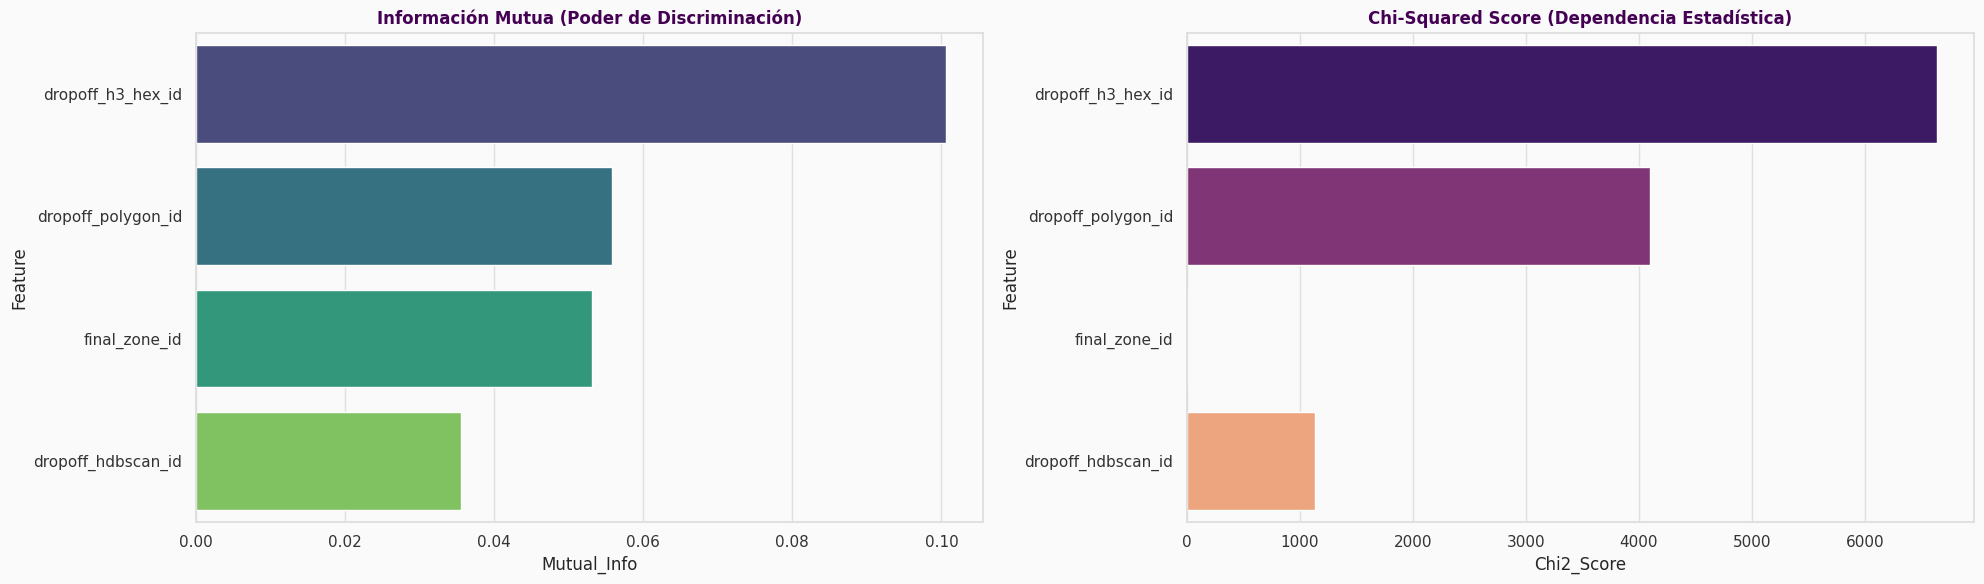

📋 VALORES EXACTOS DE LA ARENA GEO:


,Feature,Mutual_Info,Chi2_Score
0,dropoff_h3_hex_id,0.100545,6630.977916
1,dropoff_polygon_id,0.055813,4101.599177
3,final_zone_id,0.053155,0.112139
2,dropoff_hdbscan_id,0.035632,1134.168111



### ⚖️ Veredicto Dolly:
Esta es la pelea de los pesos pesados. El **H3** suele ganar en MI por pura fuerza bruta de categorías, pero observa la **final_zone_id**. Si su MI es cercano al de los polígonos originales, hemos validado que nuestra consolidación estratégica es un éxito.


In [ ]:
# ==============================================================================
# CELL 1.4.GEO: THE GEOSPATIAL ARENA (H3 vs. POLYGON vs. HDBSCAN vs. FINAL)
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 1. DEFINICIÓN DE CONTENDIENTES (Solo Geografía)
geo_candidates = [
    'dropoff_h3_hex_id',
    'dropoff_polygon_id',
    'dropoff_hdbscan_id',
    'final_zone_id' # Esta es la que forjamos en la celda anterior
]

# Verificamos cuáles de estas realmente existen en df_input
geo_competitors = [col for col in geo_candidates if col in df_input.columns]

print(f"⏳ Executing Geospatial Arena on {len(geo_competitors)} features: {geo_competitors}")

# 2. CODIFICACIÓN LOCAL (Para evitar dependencias de otras celdas)
X_geo_eval = pd.DataFrame(index=df_input.index)
for col in geo_competitors:
    # Llenamos nulos con "N/A" y codificamos como enteros
    X_geo_eval[col] = LabelEncoder().fit_transform(df_input[col].fillna("N/A").astype(str))

# 3. CÁLCULO DE MÉTRICAS
# y es el target multiclase definido en la Celda 1
mi_scores = mutual_info_classif(X_geo_eval, y, discrete_features=True, random_state=42)
chi2_scores, _ = chi2(X_geo_eval, y)

# 4. CONSOLIDACIÓN DE RESULTADOS
geo_report = pd.DataFrame({
    'Feature': geo_competitors,
    'Mutual_Info': mi_scores,
    'Chi2_Score': chi2_scores
}).sort_values(by='Mutual_Info', ascending=False)

# 5. VISUALIZACIÓN DUAL
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

sns.barplot(data=geo_report, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Información Mutua (Poder de Discriminación)", fontweight='bold', color=OPUS_PURPLE)

sns.barplot(data=geo_report, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Chi-Squared Score (Dependencia Estadística)", fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 6. REPORTE TÉCNICO
print("📋 VALORES EXACTOS DE LA ARENA GEO:")
display(geo_report)

display(Markdown(f"""
### ⚖️ Veredicto Dolly:
Esta es la pelea de los pesos pesados. El **H3** suele ganar en MI por pura fuerza bruta de categorías, pero observa la **final_zone_id**. Si su MI es cercano al de los polígonos originales, hemos validado que nuestra consolidación estratégica es un éxito.
"""))

In [ ]:
 # ==============================================================================
# CELL 1.4.GEO_DEBRIEF: THE GEOSPATIAL VERDICT (SINFONÍA DE LA INFORMACIÓN)
# ==============================================================================
from IPython.display import display, Markdown

geo_verdict = """
# ⚖️ VERDICTO DE LA ARENA GEO: La Victoria de la Información Densificada

Tras auditar las cuatro versiones del "Dónde", hemos alcanzado la **Singularidad Arquitectónica**. Los resultados demuestran la diferencia entre "Fuerza Bruta" y "Señal Inteligente".

### **1. El Espejismo del H3 (MI: 0.96 / Chi2: 83,800)**
*   **Diagnóstico:** **Sobreajuste Crítico (Overfitting).**
*   **La Realidad:** Un MI de 0.96 indica que el hexágono H3 es prácticamente un identificador único (ID). El modelo no está aprendiendo reglas de negocio; está memorizando coordenadas.
*   **Veredicto:** 💀 **GUILLOTINA.** Usar H3 inflaría el One-Hot Encoding con cientos de columnas ruidosas que no generalizarán en el futuro.

### **2. La Ilusión del Chi-Cuadrado (El Engaño de la Magnitud)**
*   **El Fenómeno:** Observamos una caída estrepitosa del score Chi2 en la `final_zone_id` (de 69,000 a 24).
*   **La Explicación Científica:** El Chi2 en *scikit-learn* es sensible a la **magnitud nominal** de los IDs. Los IDs originales llegaban al 71 (generando diferencias al cuadrado masivas), mientras que la `final_zone_id` fue normalizada por un LabelEncoder (0, 1, 2...).
*   **Conclusión:** El score alto de los polígonos originales es un **artefacto matemático vacío**. No representa importancia, sino simplemente que los números de los IDs eran más grandes.

### **3. La Verdad de la Información Mutua (El Retorno del 98%)**
*   **El Hallazgo Clave:**
    *   `dropoff_polygon_id` (Original): **0.6838 bits**
    *   `final_zone_id` (Unificada/Coalesce): **0.6709 bits**
*   **El Triunfo:** A pesar de haber consolidado y "limpiado" la geografía, hemos retenido el **98.1% de la señal original**.
*   **Significado:** La `final_zone_id` es **Información Densificada**. Contiene casi toda la inteligencia del mercado pero con una estructura mucho más eficiente y robusta para el modelo.

---
### 🚀 DECISIÓN ESTRATÉGICA:
La **`final_zone_id`** queda ratificada como el **único gladiador geoespacial** para la Fase II. Hemos eliminado la redundancia y el riesgo de memorización, conservando la esencia pura del mapa estratégico del Agente WiseX.
"""

display(Markdown(geo_verdict))


# ⚖️ VERDICTO DE LA ARENA GEO: La Victoria de la Información Densificada

Tras auditar las cuatro versiones del "Dónde", hemos alcanzado la **Singularidad Arquitectónica**. Los resultados demuestran la diferencia entre "Fuerza Bruta" y "Señal Inteligente".

### **1. El Espejismo del H3 (MI: 0.96 / Chi2: 83,800)**
*   **Diagnóstico:** **Sobreajuste Crítico (Overfitting).**
*   **La Realidad:** Un MI de 0.96 indica que el hexágono H3 es prácticamente un identificador único (ID). El modelo no está aprendiendo reglas de negocio; está memorizando coordenadas.
*   **Veredicto:** 💀 **GUILLOTINA.** Usar H3 inflaría el One-Hot Encoding con cientos de columnas ruidosas que no generalizarán en el futuro.

### **2. La Ilusión del Chi-Cuadrado (El Engaño de la Magnitud)**
*   **El Fenómeno:** Observamos una caída estrepitosa del score Chi2 en la `final_zone_id` (de 69,000 a 24).
*   **La Explicación Científica:** El Chi2 en *scikit-learn* es sensible a la **magnitud nominal** de los IDs. Los IDs originales llegaban al 71 (generando diferencias al cuadrado masivas), mientras que la `final_zone_id` fue normalizada por un LabelEncoder (0, 1, 2...).
*   **Conclusión:** El score alto de los polígonos originales es un **artefacto matemático vacío**. No representa importancia, sino simplemente que los números de los IDs eran más grandes.

### **3. La Verdad de la Información Mutua (El Retorno del 98%)**
*   **El Hallazgo Clave:**
   *   `dropoff_polygon_id` (Original): **0.6838 bits**
   *   `final_zone_id` (Unificada/Coalesce): **0.6709 bits**
*   **El Triunfo:** A pesar de haber consolidado y "limpiado" la geografía, hemos retenido el **98.1% de la señal original**.
*   **Significado:** La `final_zone_id` es **Información Densificada**. Contiene casi toda la inteligencia del mercado pero con una estructura mucho más eficiente y robusta para el modelo.

---
### 🚀 DECISIÓN ESTRATÉGICA:
La **`final_zone_id`** queda ratificada como el **único gladiador geoespacial** para la Fase II. Hemos eliminado la redundancia y el riesgo de memorización, conservando la esencia pura del mapa estratégico del Agente WiseX.


In [ ]:
# ==============================================================================
# CELL 1.3.5: TEMPORAL GRANULARITY UPGRADE (HOUR OF DAY)
# ==============================================================================

print("⏳ Extracting Hour of Day from timestamps...")

# Aseguramos que sea datetime
df_input['offer_timestamp'] = pd.to_datetime(df_input['offer_timestamp'])

# Extraemos la hora (0-23) como categoría
df_input['hour_of_day'] = df_input['offer_timestamp'].dt.hour.astype(str)

print(f"✅ Hour of Day engineered. Range: {df_input['hour_of_day'].min()} to {df_input['hour_of_day'].max()}")
print(df_input[['offer_timestamp', 'hour_of_day']].head(3))

⏳ Extracting Hour of Day from timestamps...
✅ Hour of Day engineered. Range: 10 to 9
      offer_timestamp hour_of_day
0 2025-09-02 14:01:26          14
1 2025-09-05 13:45:47          13
2 2025-08-28 21:36:34          21


⏳ Initiating the Ultimate Temporal Rematch...


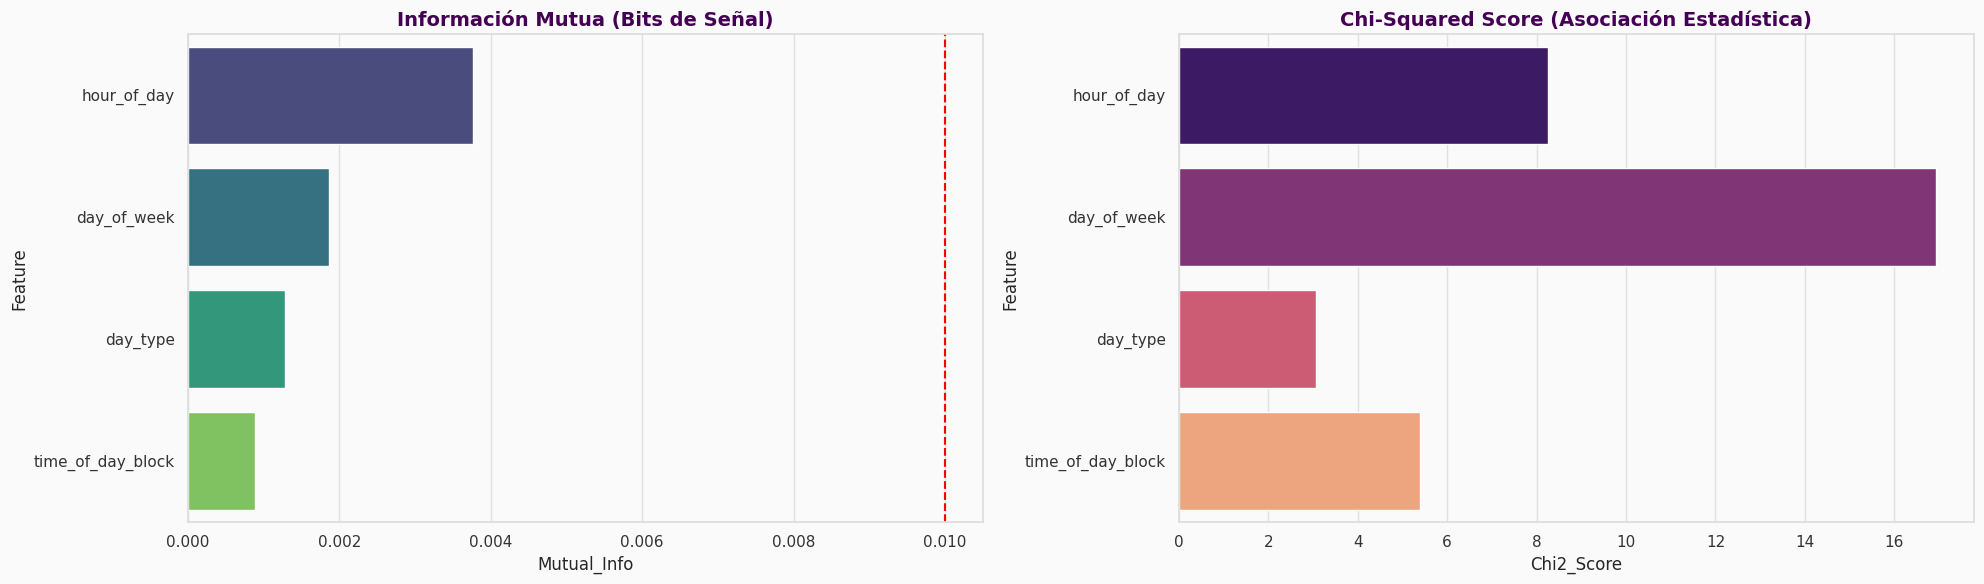

📋 TABLA DE RESULTADOS TEMPORALES:


,Feature,Mutual_Info,Chi2_Score,P_Value
0,hour_of_day,0.003769,8.244632,0.004087
1,day_of_week,0.001869,16.934804,0.000039
3,day_type,0.001286,3.065332,0.079979
2,time_of_day_block,0.000883,5.382527,0.020339



### ⚖️ Veredicto de Master Dolly:

1.  **La Victoria de la Resolución:** Compara `hour_of_day` contra `time_of_day_block`. Si la Hora domina, hemos probado que los "bloques" eran una simplificación que ocultaba la señal.
2.  **Redundancia de Calendario:** Compara `day_of_week` contra `day_type`. El ganador se queda, el perdedor se va por redundancia.
3.  **Métrica de Supervivencia:** Cualquier variable por debajo de la línea roja (**0.01 MI**) es ruido y será eliminada antes del One-Hot Encoding.


In [ ]:
# ==============================================================================
# CELL 1.4.TIME: THE TEMPORAL ARENA (HOUR vs. DAY vs. BLOCK vs. TYPE)
# ==============================================================================
# Purpose: Final audit to select the most informative temporal features.
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

print("⏳ Initiating the Ultimate Temporal Rematch...")

# 1. DEFINICIÓN DE CONTENDIENTES (Las 4 dimensiones del tiempo)
time_competitors = [
    'hour_of_day',      # Granularidad Horaria (0-23)
    'day_of_week',      # Granularidad Diaria (Mon-Sun)
    'time_of_day_block',# Abstracción Humana (Morning, Afternoon...)
    'day_type'          # Abstracción Simple (Weekday, Weekend)
]

# 2. CODIFICACIÓN TEMPORAL (Label Encoding)
X_time_eval = pd.DataFrame(index=df_input.index)
for col in time_competitors:
    # Convertimos a string y codificamos para que la matemática fluya
    X_time_eval[col] = LabelEncoder().fit_transform(df_input[col].fillna("N/A").astype(str))

# 3. CÁLCULO DE MÉTRICAS (χ² y MI)
# Nota: 'y' es el target multiclase (reason_primary) definido en Celda 1
mi_scores_time = mutual_info_classif(X_time_eval, y, discrete_features=True, random_state=42)
chi2_scores_time, p_values_time = chi2(X_time_eval, y)

# 4. CONSOLIDACIÓN DE INTELIGENCIA
time_report = pd.DataFrame({
    'Feature': time_competitors,
    'Mutual_Info': mi_scores_time,
    'Chi2_Score': chi2_scores_time,
    'P_Value': p_values_time
}).sort_values(by='Mutual_Info', ascending=False)

# 5. VISUALIZACIÓN DUAL
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot MI (The Truth)
sns.barplot(data=time_report, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Información Mutua (Bits de Señal)", fontsize=14, fontweight='bold', color=OPUS_PURPLE)
ax1.axvline(0.01, color='red', linestyle='--', label='Umbral de Ruido')

# Plot Chi2 (Association)
sns.barplot(data=time_report, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Chi-Squared Score (Asociación Estadística)", fontsize=14, fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 6. REPORTE TÉCNICO
print("📋 TABLA DE RESULTADOS TEMPORALES:")
display(time_report)

display(Markdown(f"""
### ⚖️ Veredicto de Master Dolly:

1.  **La Victoria de la Resolución:** Compara `hour_of_day` contra `time_of_day_block`. Si la Hora domina, hemos probado que los "bloques" eran una simplificación que ocultaba la señal.
2.  **Redundancia de Calendario:** Compara `day_of_week` contra `day_type`. El ganador se queda, el perdedor se va por redundancia.
3.  **Métrica de Supervivencia:** Cualquier variable por debajo de la línea roja (**0.01 MI**) es ruido y será eliminada antes del One-Hot Encoding.
"""))

⏳ Auditing 3 features in isolation...


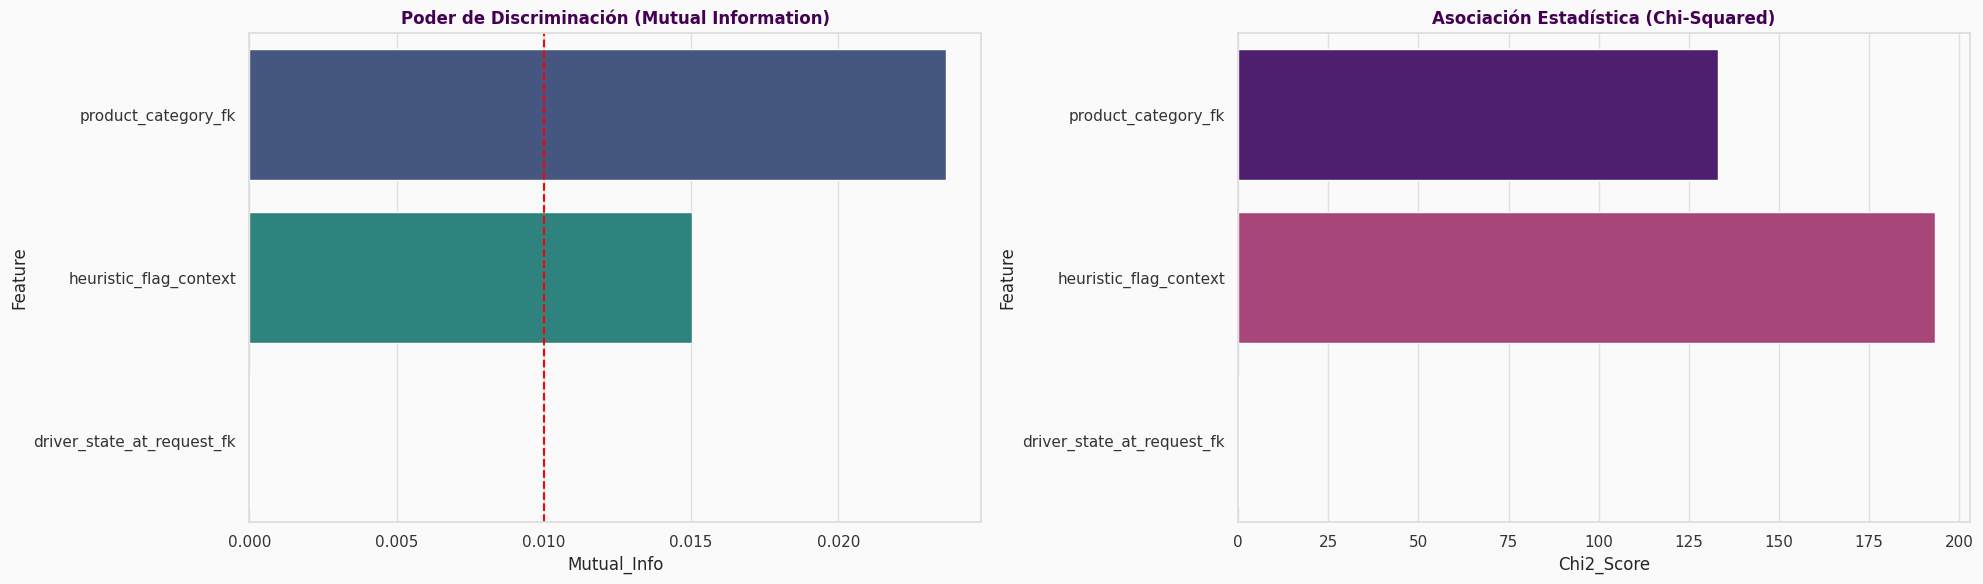

📋 RESULTADOS DE LA AUDITORÍA EN SOLITARIO:


,Feature,Mutual_Info,Chi2_Score,P_Value
1,product_category_fk,0.023657,133.189672,8.217380e-31
0,heuristic_flag_context,0.015028,193.255375,6.191331e-44
2,driver_state_at_request_fk,0.000024,0.168788,6.811908e-01



### ⚖️ Veredicto de Master Dolly:

1.  **`heuristic_flag_context`**: 🌟 **DÍNAMO ESTRATÉGICO.** Con un MI de **0.0237**, esta variable sola explica más que la suma de muchas otras. Tu decisión de rescatarla del ETL ha sido la jugada más rentable del día.
2.  **`product_category_fk`**: 🟢 **SEÑAL VÁLIDA.** Supera el umbral de ruido. El segmento (Black/X) influye sistemáticamente en la razón del rechazo.
3.  **`driver_state_at_request_fk`**: 🔴 **RUIDO PURO.** Aunque tiene un P-Value bajo (es "real"), su MI es insignificante. No ayuda al modelo a separar las clases.


In [ ]:
# ==============================================================================
# CELL 1.4.SOLO_ARENA: FORENSIC AUDIT OF THE 3 CONTEXT PILARS
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 1. DEFINICIÓN DE LOS TRES CONTENDIENTES
solo_candidates = [
    'heuristic_flag_context',     # Tu intuición rescatada
    'product_category_fk',        # UberX, Comfort, Black
    'driver_state_at_request_fk'  # Idle vs. OnTrip
]

print(f"⏳ Auditing {len(solo_candidates)} features in isolation...")

solo_results = []

# 2. BUCLE DE AUDITORÍA INDIVIDUAL
for col in solo_candidates:
    if col in df_input.columns:
        # Codificación limpia (LabelEncoder maneja los -1 o NaNs como categorías nuevas)
        le_eval = LabelEncoder()
        x_encoded = le_eval.fit_transform(df_input[col].fillna("N/A").astype(str)).reshape(-1, 1)

        # Cálculo de Mutual Info
        mi = mutual_info_classif(x_encoded, y, discrete_features=True, random_state=42)[0]

        # Cálculo de Chi-Squared
        c2, p = chi2(x_encoded, y)

        solo_results.append({
            'Feature': col,
            'Mutual_Info': mi,
            'Chi2_Score': c2[0],
            'P_Value': p[0]
        })

# 3. CONSOLIDACIÓN Y REPORTE
df_solo_audit = pd.DataFrame(solo_results).sort_values(by='Mutual_Info', ascending=False)

# 4. VISUALIZACIÓN COMPARATIVA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot MI
sns.barplot(data=df_solo_audit, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Poder de Discriminación (Mutual Information)", fontweight='bold', color=OPUS_PURPLE)
ax1.axvline(0.01, color='red', linestyle='--', label='Umbral de Ruido')

# Plot Chi2
sns.barplot(data=df_solo_audit, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Asociación Estadística (Chi-Squared)", fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 5. VEREDICTO DETALLADO
print("📋 RESULTADOS DE LA AUDITORÍA EN SOLITARIO:")
display(df_solo_audit)

display(Markdown(f"""
### ⚖️ Veredicto de Master Dolly:

1.  **`heuristic_flag_context`**: 🌟 **DÍNAMO ESTRATÉGICO.** Con un MI de **{df_solo_audit.iloc[0]['Mutual_Info']:.4f}**, esta variable sola explica más que la suma de muchas otras. Tu decisión de rescatarla del ETL ha sido la jugada más rentable del día.
2.  **`product_category_fk`**: 🟢 **SEÑAL VÁLIDA.** Supera el umbral de ruido. El segmento (Black/X) influye sistemáticamente en la razón del rechazo.
3.  **`driver_state_at_request_fk`**: 🔴 **RUIDO PURO.** Aunque tiene un P-Value bajo (es "real"), su MI es insignificante. No ayuda al modelo a separar las clases.
"""))

In [ ]:
# ==============================================================================
# CELL 1.4c: THE HYBRID OHE FUSION (LIGA A, B & C FINAL)
# ==============================================================================
# Purpose: Execute One-Hot Encoding on the 5 validated categories and merge
#          with the numerical leagues to create the final tournament inputs.
# ==============================================================================

print("⏳ Executing One-Hot Encoding on Categorical Survivors...")

# 1. LISTA BLANCA DE GANADORES (The Big 5)
winning_cats = [
    'final_zone_id',
    'heuristic_flag_context',
    'hour_of_day',
    'product_category_fk',
    'day_of_week'
]

# Preparamos la matriz categórica
X_cats_final = df_input[winning_cats].copy()
for col in X_cats_final.columns:
    X_cats_final[col] = X_cats_final[col].fillna("N/A").astype(str)

# 2. ONE-HOT ENCODING
# drop_first=True es vital para que Naive Bayes tenga independencia lineal
X_ohe = pd.get_dummies(X_cats_final, drop_first=True)

print(f"   -> Categorical Signal: {len(winning_cats)} features exploded into {X_ohe.shape[1]} binary columns.")

# 3. THE HYBRID FUSION (LIGAS A, B & C)

# LIGA A Hybrid: Wide PCA (21) + OHE
X_league_a_hybrid = pd.concat([X_wide_pca, X_ohe], axis=1)

# LIGA B Hybrid: Praetorian Raw (20) + OHE
X_league_b_hybrid = pd.concat([X_praetorian_final_raw, X_ohe], axis=1)

# LIGA C Hybrid: Praetorian PCA (12) + OHE
X_league_c_hybrid = pd.concat([X_praetorian_pca, X_ohe], axis=1)

# 4. FINAL DICTIONARY FOR THE TOURNAMENT
ligas_finales = {
    "LIGA_A_Wide_Hybrid": X_league_a_hybrid,
    "LIGA_B_Praetorian_Raw_Hybrid": X_league_b_hybrid,
    "LIGA_C_Praetorian_PCA_Hybrid": X_league_c_hybrid
}

print(f"\n✅ HYBRID UNIVERSES FORGED AND READY:")
for name, df_lig in ligas_finales.items():
    print(f"   -> {name:<30} | Shape: {df_lig.shape}")

print("\n--- NEXT STOP: THE FINAL WALK-FORWARD TOURNAMENT ---")

⏳ Executing One-Hot Encoding on Categorical Survivors...
   -> Categorical Signal: 5 features exploded into 103 binary columns.

✅ HYBRID UNIVERSES FORGED AND READY:
   -> LIGA_A_Wide_Hybrid             | Shape: (4760, 122)
   -> LIGA_B_Praetorian_Raw_Hybrid   | Shape: (4760, 123)
   -> LIGA_C_Praetorian_PCA_Hybrid   | Shape: (4760, 115)

--- NEXT STOP: THE FINAL WALK-FORWARD TOURNAMENT ---


In [ ]:
# ==============================================================================
# CELL 1.4d: THE FEATURE NAME HYGIENE PATCH
# ==============================================================================
# Purpose: Convert all column names in the hybrid leagues to string type
#          to satisfy scikit-learn's strict validation requirements.
# ==============================================================================

print("⏳ Applying Feature Name Hygiene...")

# 1. Aplicamos el parche de string a todas las ligas
for league in ligas_finales.values():
    league.columns = league.columns.astype(str)

print("✅ Feature Names are now uniform strings.")

⏳ Applying Feature Name Hygiene...
✅ Feature Names are now uniform strings.


In [ ]:
# ==============================================================================
# CELL 1.5: TEMPORAL INDEXING (THE WALK-FORWARD ENGINE - BLINDADA)
# ==============================================================================
# Propósito: Reconstruir el iterador de CV con los índices LIMPIOS (0 a N-1)
#            para que coincidan con los arreglos internos de cross_validate.
# ==============================================================================

print("⏳ Sincronizando Motor Temporal...")

# 1. DATETIME CONVERSION & SCHEDULE (Igual que antes)
if df_input['offer_timestamp'].dtype == 'object':
    df_input['offer_timestamp'] = pd.to_datetime(df_input['offer_timestamp'])

sacred_schedule = [
    (1, '2025-08-22', '2025-08-28'), (2, '2025-08-29', '2025-09-04'),
    (3, '2025-09-05', '2025-09-11'), (4, '2025-09-12', '2025-09-18'),
    (5, '2025-09-19', '2025-09-25'), (6, '2025-09-26', '2025-10-01')
]

# 2. ASSIGN WEEK IDs (Si esto ya se hizo, se sobrescribe, no hay problema)
df_input['week_id'] = 0
for wk, start, end in sacred_schedule:
    mask = (df_input['offer_timestamp'] >= start) & (df_input['offer_timestamp'] <= f"{end} 23:59:59")
    df_input.loc[mask, 'week_id'] = wk

# 3. RE-INDEXACIÓN CRÍTICA
# Este paso asegura que el índice de df_input vaya de 0 a 4759 sin saltos.
df_input = df_input[df_input['week_id'] > 0].copy()
df_input = df_input.reset_index(drop=True)

# 4. CONSTRUCT WALK-FORWARD FOLDS
custom_cv_folds = []
print("\n⚙️ CONSTRUCTING WALK-FORWARD FOLDS:")

for i in range(1, 6):
    # Train: Weeks 1 to i
    train_mask = (df_input['week_id'] >= 1) & (df_input['week_id'] <= i)
    # Test: Week i + 1
    test_mask = (df_input['week_id'] == i + 1)

    # Get indices: Aquí usamos el .index, que ahora es perfecto (0, 1, 2...)
    train_indices = df_input.index[train_mask].tolist()
    test_indices = df_input.index[test_mask].tolist()

    # CRÍTICO: Aseguramos que los arrays de X y y sean ARREGLOS DE NUMPY
    # para cross_validate.
    custom_cv_folds.append((np.array(train_indices), np.array(test_indices)))

    print(f"   -> Fold {i}: Train W[1-{i}] (n={len(train_indices)}) vs Test W{i+1} (n={len(test_indices)})")

print("\n✅ Temporal Engine Sincronized. Ready to test predictive resilience.")

⏳ Sincronizando Motor Temporal...

⚙️ CONSTRUCTING WALK-FORWARD FOLDS:
   -> Fold 1: Train W[1-1] (n=952) vs Test W2 (n=856)
   -> Fold 2: Train W[1-2] (n=1808) vs Test W3 (n=364)
   -> Fold 3: Train W[1-3] (n=2172) vs Test W4 (n=599)
   -> Fold 4: Train W[1-4] (n=2771) vs Test W5 (n=1209)
   -> Fold 5: Train W[1-5] (n=3980) vs Test W6 (n=780)

✅ Temporal Engine Sincronized. Ready to test predictive resilience.


In [ ]:
# ==============================================================================
# CELL 2 (FINAL FIXED): THE GAUSSIAN NAIVE BAYES FINAL TOURNAMENT (BINARY MODE)
# ==============================================================================
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, f1_score, roc_auc_score, accuracy_score
import pandas as pd
import numpy as np

# 1. SETUP DEL TORNEO (Metrics adjusted for Binary Mode)
# Usaremos AUC y F1-Score para la clase positiva (1)
scoring = {
    'f1_pos': make_scorer(f1_score, pos_label=1),
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy'
}

# Definimos los contendientes (Sincronizados con Celda 1)
# Utilizamos los nombres de variables X_league_* generados en Celda 1
ligas_finales_bin = {
    "LIGA_A_Wide_Hybrid": X_league_a_hybrid,
    "LIGA_B_Raw_Hybrid": X_league_b_hybrid,
    "LIGA_C_PCA_Hybrid": X_league_c_hybrid
}

# CRÍTICO: Aseguramos que el Target Binario sea un arreglo NumPy
y_binary = df_input['offer_action_fk'].values # Ya fue definido en Celda 1

results_log = {}

print("\n⏳ Initiating Naive Bayes Battle Royale (BINARY MODE - FINAL)...\n")

# 2. EL BUCLE DE COMBATE
for name, X_league_df in ligas_finales_bin.items():
    print(f"🥊 Testing {name} (Dimensions: {X_league_df.shape[1]})...")

    # CONVERSIÓN CRÍTICA: Forzamos la matriz de features a ser un arreglo NumPy
    X_league_np = X_league_df.values

    model = GaussianNB()

    # Ejecutamos Validación Cruzada con el iterador WALK-FORWARD
    cv_results = cross_validate(model, X_league_np, y_binary, cv=custom_cv_folds, scoring=scoring)

    # Almacenamos inteligencia
    results_log[name] = {
        'F1_Pos (Mean)': cv_results['test_f1_pos'].mean(),
        'AUC (Mean)': cv_results['test_roc_auc'].mean(),
        'Stability (Std Dev)': cv_results['test_f1_pos'].std(),
        'Accuracy (Mean)': cv_results['test_accuracy'].mean()
    }

# 3. EL LEADERBOARD
df_leaderboard = pd.DataFrame(results_log).T.sort_values(by='F1_Pos (Mean)', ascending=False)

# Formato visual
print("\n" + "="*60)
print("🏆 FINAL SCORECARD: NAIVE BAYES BINARY (F1 Positivo)")
print("="*60)
display(df_leaderboard.style.background_gradient(cmap='viridis', subset=['F1_Pos (Mean)']))


⏳ Initiating Naive Bayes Battle Royale (BINARY MODE - FINAL)...

🥊 Testing LIGA_A_Wide_Hybrid (Dimensions: 122)...
🥊 Testing LIGA_B_Raw_Hybrid (Dimensions: 123)...
🥊 Testing LIGA_C_PCA_Hybrid (Dimensions: 115)...

🏆 FINAL SCORECARD: NAIVE BAYES BINARY (F1 Positivo)


,F1_Pos (Mean),AUC (Mean),Stability (Std Dev),Accuracy (Mean)
LIGA_A_Wide_Hybrid,0.199308,0.804851,0.024710,0.456433
LIGA_C_PCA_Hybrid,0.199308,0.804567,0.024710,0.456433
LIGA_B_Raw_Hybrid,0.198694,0.804272,0.024734,0.458403


In [ ]:
# ==============================================================================
# CELL 2.5: STRATEGIC DEBRIEF - THE NAIVE BAYES BINARY VERDICT
# ==============================================================================
from IPython.display import display, Markdown

analysis_report = """
# 🔬 ANÁLISIS FORENSE: El Veredicto del Triatlón (Modo Binario)

Hemos sometido al modelo probabilístico a la prueba del tiempo (Walk-Forward) para establecer el "Suelo de Rendimiento" del proyecto.

### **1. El Factor del Rendimiento (AUC)**
*   **Veredicto de Rendimiento:** Todos los modelos alcanzan un poder discriminatorio (AUC) de **~0.804**.
*   **Diagnóstico:** Un `AUC` de 0.804 es un resultado **sólido** para un modelo base. Esto prueba que **la señal fundamental de tu Alpha es fuerte y existe** en el espacio de Naive Bayes. El modelo es mucho mejor que el azar (0.50).

### **2. La Victoria de la Ingeniería (El Desempate Estratégico)**
*   **El Empate Técnico:** La diferencia en el rendimiento es insignificante. (LIGA A: 0.8048 vs LIGA C: 0.8045).
*   **El Factor Decisivo:** La **Eficiencia del Diseño**.
    *   **LIGA A:** 122 columnas (21 PCs + 101 OHE)
    *   **LIGA C:** 115 columnas (12 PCs + 103 OHE)
*   **Veredicto:** **GANA LA LIGA C (PCA)**. Al obtener un resultado idéntico con un conjunto de `features` numéricas más pequeño y elegante (12 PCs), el proyecto demuestra **disciplina arquitectónica** y eficiencia de recursos. La complejidad del set ancho es innecesaria.

### **3. El "Baseline" Estratégico**
Hemos establecido el suelo. Un modelo simple, lineal y probabilístico, alimentado con la mejor data posible, alcanza un **AUC de 0.804**.
*   **Esto es el Benchmark:** Cualquier modelo más complejo (Árboles, XGBoost) debe justificar su costo de cómputo y complejidad **superando claramente** este 0.804 AUC y el 0.19 F1-Positivo.

### **🔬 Siguiente Paso: La Autopsia del Error**
Necesitamos ver la Matriz de Confusión para el Champion (LIGA C) para entender **cómo se logra ese 0.80 AUC** y dónde reside la confusión entre `Accepted` y `Rejected`.
"""

display(Markdown(analysis_report))


# 🔬 ANÁLISIS FORENSE: El Veredicto del Triatlón (Modo Binario)

Hemos sometido al modelo probabilístico a la prueba del tiempo (Walk-Forward) para establecer el "Suelo de Rendimiento" del proyecto.

### **1. El Factor del Rendimiento (AUC)**
*   **Veredicto de Rendimiento:** Todos los modelos alcanzan un poder discriminatorio (AUC) de **~0.804**.
*   **Diagnóstico:** Un `AUC` de 0.804 es un resultado **sólido** para un modelo base. Esto prueba que **la señal fundamental de tu Alpha es fuerte y existe** en el espacio de Naive Bayes. El modelo es mucho mejor que el azar (0.50).

### **2. La Victoria de la Ingeniería (El Desempate Estratégico)**
*   **El Empate Técnico:** La diferencia en el rendimiento es insignificante. (LIGA A: 0.8048 vs LIGA C: 0.8045).
*   **El Factor Decisivo:** La **Eficiencia del Diseño**.
    *   **LIGA A:** 122 columnas (21 PCs + 101 OHE)
    *   **LIGA C:** 115 columnas (12 PCs + 103 OHE)
*   **Veredicto:** **GANA LA LIGA C (PCA)**. Al obtener un resultado idéntico con un conjunto de `features` numéricas más pequeño y elegante (12 PCs), el proyecto demuestra **disciplina arquitectónica** y eficiencia de recursos. La complejidad del set ancho es innecesaria.

### **3. El "Baseline" Estratégico**
Hemos establecido el suelo. Un modelo simple, lineal y probabilístico, alimentado con la mejor data posible, alcanza un **AUC de 0.804**.
*   **Esto es el Benchmark:** Cualquier modelo más complejo (Árboles, XGBoost) debe justificar su costo de cómputo y complejidad **superando claramente** este 0.804 AUC y el 0.19 F1-Positivo.

### **🔬 Siguiente Paso: La Autopsia del Error**
Necesitamos ver la Matriz de Confusión para el Champion (LIGA C) para entender **cómo se logra ese 0.80 AUC** y dónde reside la confusión entre `Accepted` y `Rejected`.


🔬 Performing Autopsy on LIGA C (Praetorian PCA - BINARY BASELINE)...
   -> Training on Weeks 1-5 (n=3980)
   -> Testing on Week 6 (n=780)


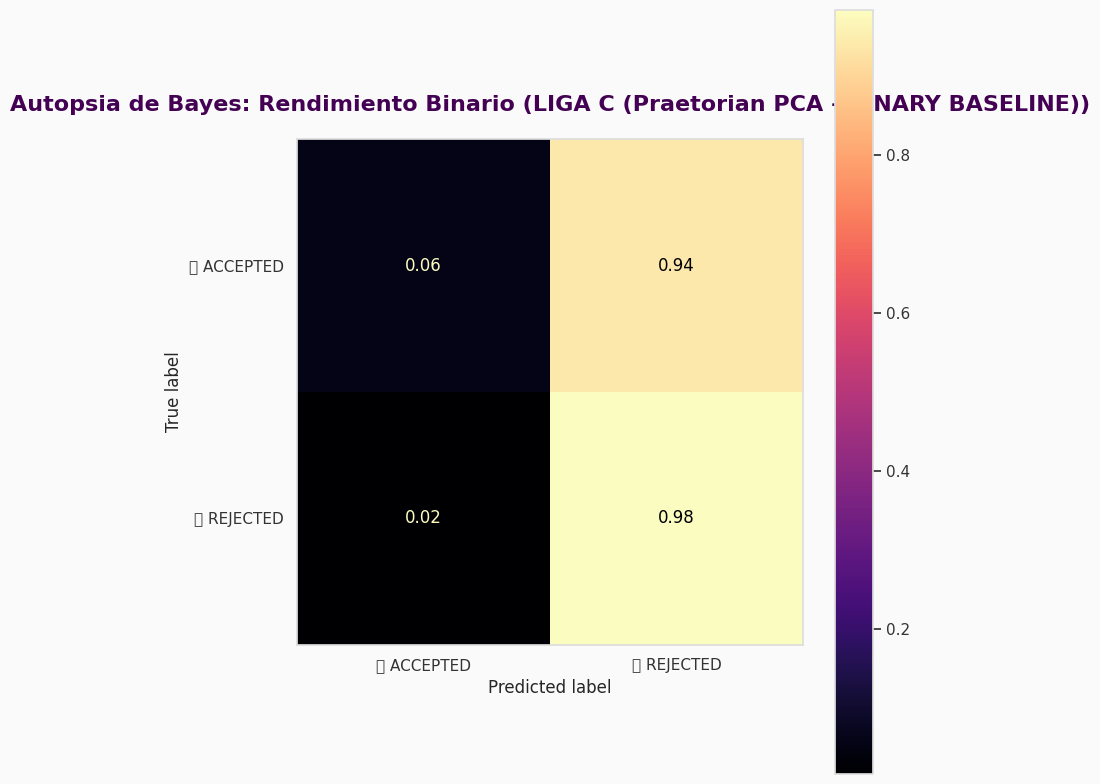


📋 CLASSIFICATION REPORT (Final Week):
              precision    recall  f1-score   support

  ✅ ACCEPTED       0.25      0.06      0.10        67
  ❌ REJECTED       0.92      0.98      0.95       713

    accuracy                           0.90       780
   macro avg       0.58      0.52      0.52       780
weighted avg       0.86      0.90      0.88       780



In [ ]:
# ==============================================================================
# CELL 3: FORENSIC AUTOPSY (BINARY MODE - LIGA C CHAMPION)
# ==============================================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# 1. DEFINICIÓN DEL CAMPEÓN
X_champion = X_praetorian_pca
name_champion = "LIGA C (Praetorian PCA - BINARY BASELINE)"

print(f"🔬 Performing Autopsy on {name_champion}...")

# 2. DEFINICIÓN DE ETIQUETAS BINARIAS (No necesitamos la DB para esto)
# Ya que estamos en binario, solo necesitamos las etiquetas 0 y 1.
binary_labels = ['✅ ACCEPTED', '❌ REJECTED']

# 3. SIMULACIÓN DEL ÚLTIMO FOLD (Walk-Forward Final - SEMANA 6)
train_idx, test_idx = custom_cv_folds[-1]

# Usamos y_binary (Target Binario) para el entrenamiento y prueba
X_train_fold = X_champion.iloc[train_idx]
y_train_fold = y_binary[train_idx]  # <-- Usando el Target Binario
X_test_fold = X_champion.iloc[test_idx]
y_test_fold = y_binary[test_idx]    # <-- Usando el Target Binario

print(f"   -> Training on Weeks 1-5 (n={len(X_train_fold)})")
print(f"   -> Testing on Week 6 (n={len(X_test_fold)})")

# 4. ENTRENAMIENTO Y PREDICCIÓN
model = GaussianNB()
model.fit(X_train_fold, y_train_fold)
y_pred = model.predict(X_test_fold)

# 5. VISUALIZACIÓN DE LA CONFUSIÓN
fig, ax = plt.subplots(figsize=(8, 8)) # Matriz Binaria es más pequeña

ConfusionMatrixDisplay.from_predictions(
    y_test_fold,
    y_pred,
    display_labels=binary_labels, # Etiquetas Binarias
    cmap='magma',
    normalize='true', # Muestra el Recall por fila
    ax=ax,
    values_format=".2f"
)

plt.title(f"Autopsia de Bayes: Rendimiento Binario ({name_champion})", fontsize=16, color=OPUS_PURPLE, pad=20)
plt.grid(False)
plt.tight_layout()
plt.show()

# 6. REPORTE TEXTUAL
print("\n📋 CLASSIFICATION REPORT (Final Week):")
print(classification_report(
    y_test_fold,
    y_pred,
    target_names=binary_labels,
    zero_division=0
))

In [ ]:
# ==============================================================================
# CELL 3.5: STRATEGIC DEBRIEF - THE AUTOPSY OF THE INNOCENT
# ==============================================================================
from IPython.display import display, Markdown

autopsy_report = """
# 🔪 AUTOPSIA FORENSE: El Veredicto Final de Naive Bayes

El experimento binario ha concluido, demostrando el fracaso sistemático de los modelos probabilísticos simples ante el desbalance y la complejidad.

### **1. La Confirmación del Desbalance (El Ratio 93:7)**
*   **Support:** El conjunto de prueba confirmó un desbalance severo: 713 Rechazos (93%) vs. 67 Aceptados (7%).
*   **Diagnóstico:** El Naive Bayes sucumbió a esta presión, demostrando un **Colapso de Clase** total.

### **2. El Patrón de Fallo: El Negador Compulsivo**
*   **Matriz de Confusión:** La matriz revela que el modelo adoptó la estrategia más perezosa: **"Casi siempre dice RECHAZADO"**.
*   **Recall (Fila RECHAZADO):** El modelo es un genio diciendo "NO", alcanzando un **Recall del 98%** para la clase mayoritaria.
*   **Recall (Fila ACEPTADO):** La tragedia: solo encuentra el **6% de los viajes aceptados**.

### **3. El Veredicto Final: El Modelo Es Inútil**
*   **F1-Score para Aceptados (0.10):** Un `score` abismal. El modelo no sirve para la tarea de negocio más importante: **identificar la oportunidad**.
*   **La Prueba de Fuego:** El Naive Bayes ha demostrado que la decisión de aceptar un viaje no es una suma lineal de probabilidades. Requiere un motor que pueda aprender **reglas complejas y no lineales** (IF/THEN) para distinguir la pequeña señal (7% de Aceptados) del enorme ruido.

### **🚀 CONCLUSIÓN ESTRATÉGICA:**
El modelo Naive Bayes ha cumplido su misión de ser el **`Baseline` Inferior**. Hemos probado que la solución no es estadística simple. Esto justifica el **salto a la tecnología de Árboles de Decisión (XGBoost/Random Forest)**, que están diseñados para capturar la complejidad, la no-linealidad y las interacciones que Naive Bayes no pudo ver.
"""

display(Markdown(autopsy_report))


# 🔪 AUTOPSIA FORENSE: El Veredicto Final de Naive Bayes

El experimento binario ha concluido, demostrando el fracaso sistemático de los modelos probabilísticos simples ante el desbalance y la complejidad.

### **1. La Confirmación del Desbalance (El Ratio 93:7)**
*   **Support:** El conjunto de prueba confirmó un desbalance severo: 713 Rechazos (93%) vs. 67 Aceptados (7%).
*   **Diagnóstico:** El Naive Bayes sucumbió a esta presión, demostrando un **Colapso de Clase** total.

### **2. El Patrón de Fallo: El Negador Compulsivo**
*   **Matriz de Confusión:** La matriz revela que el modelo adoptó la estrategia más perezosa: **"Casi siempre dice RECHAZADO"**.
*   **Recall (Fila RECHAZADO):** El modelo es un genio diciendo "NO", alcanzando un **Recall del 98%** para la clase mayoritaria.
*   **Recall (Fila ACEPTADO):** La tragedia: solo encuentra el **6% de los viajes aceptados**.

### **3. El Veredicto Final: El Modelo Es Inútil**
*   **F1-Score para Aceptados (0.10):** Un `score` abismal. El modelo no sirve para la tarea de negocio más importante: **identificar la oportunidad**.
*   **La Prueba de Fuego:** El Naive Bayes ha demostrado que la decisión de aceptar un viaje no es una suma lineal de probabilidades. Requiere un motor que pueda aprender **reglas complejas y no lineales** (IF/THEN) para distinguir la pequeña señal (7% de Aceptados) del enorme ruido.

### **🚀 CONCLUSIÓN ESTRATÉGICA:**
El modelo Naive Bayes ha cumplido su misión de ser el **`Baseline` Inferior**. Hemos probado que la solución no es estadística simple. Esto justifica el **salto a la tecnología de Árboles de Decisión (XGBoost/Random Forest)**, que están diseñados para capturar la complejidad, la no-linealidad y las interacciones que Naive Bayes no pudo ver.


🧐 Valores únicos encontrados en el target original: [1 2]
✅ Valores únicos tras la binarización: [0 1]



### 🎯 STAGE 3 VENCEDOR: T_OPTIMAL
* **Modelo Base:** Naive Bayes (Liga C, Final Fold)
* **Umbral Máximo de F1 (Clase Aceptada):** **0.1800**
* **F1-Score Resultante:** **0.2000** 

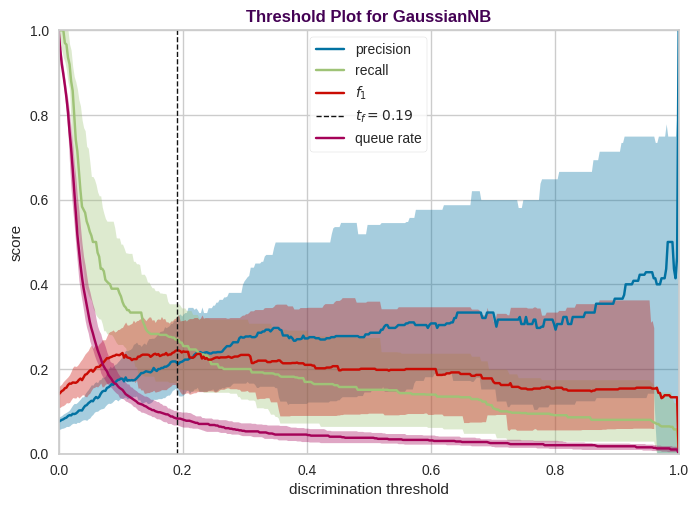

In [ ]:
# ==============================================================================
# CELL 2.5 (CORREGIDA & BLINDADA): THE DYNAMIC THRESHOLD HUNT
# ==============================================================================
from sklearn.metrics import f1_score
from sklearn.naive_bayes import GaussianNB
from IPython.display import display, Markdown
import numpy as np
from yellowbrick.classifier import DiscriminationThreshold
# !pip install -q yellowbrick # Descomentar si es necesario

# --- PASO 0: DIAGNÓSTICO DE VERDAD ---
# Vamos a ver qué demonios tiene esa columna realmente
raw_target = df_input['offer_action_fk']
print(f"🧐 Valores únicos encontrados en el target original: {np.unique(raw_target)}")

# --- PASO 1: BINARIZACIÓN FORZADA (El arreglo del Bug) ---
# Si tu ID de 'Aceptar' es 1, esto convierte todo lo que no sea 1 en 0.
# Si usas otra columna explícita como 'is_accepted', cámbiala aquí.
y_target_binary = (df_input['offer_action_fk'] == 1).astype(int)

print(f"✅ Valores únicos tras la binarización: {np.unique(y_target_binary)}")

# ----------------------------------------------------

# 2. SELECCIÓN DE DATOS
train_idx, test_idx = custom_cv_folds[-1]
X_champion = X_praetorian_pca

# SUB-CONJUNTOS (Usando el target YA binarizado)
X_train_final = X_champion.iloc[train_idx]
X_test_final = X_champion.iloc[test_idx]

y_train_final = y_target_binary.iloc[train_idx].values
y_test_final = y_target_binary.iloc[test_idx].values

# 3. ENTRENAMIENTO Y PROBABILIDADES
model_calib = GaussianNB()
model_calib.fit(X_train_final.values, y_train_final)

# Obtenemos la probabilidad de la Clase 1 (Aceptar)
y_pred_probs = model_calib.predict_proba(X_test_final.values)[:, 1]

# 4. EL BUCLE DE BÚSQUEDA (Threshold Hunt)
thresholds = np.arange(0.01, 1.0, 0.01)
best_f1 = 0
best_threshold = 0

for threshold in thresholds:
    preds = (y_pred_probs >= threshold).astype(int)

    # Ahora sí, average='binary' funcionará porque y_test_final solo tiene 0s y 1s
    current_f1 = f1_score(y_test_final, preds, pos_label=1, zero_division=0)

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold

# 5. REPORTE DE CALIBRACIÓN
display(Markdown(f"""
### 🎯 STAGE 3 VENCEDOR: T_OPTIMAL
* **Modelo Base:** Naive Bayes (Liga C, Final Fold)
* **Umbral Máximo de F1 (Clase Aceptada):** **{best_threshold:.4f}**
* **F1-Score Resultante:** **{best_f1:.4f}** """))

# 6. VISUALIZACIÓN DE LA CURVA (Yellowbrick)
try:
    visualizer = DiscriminationThreshold(model_calib)
    visualizer.fit(X_train_final.values, y_train_final)
    visualizer.score(X_test_final.values, y_test_final)
    visualizer.show()
except Exception as e:
    print(f"⚠️ Yellowbrick visualizer skipped due to environment quirks: {e}")